<a href="https://colab.research.google.com/github/nileshw10/Python-for-Data-Science/blob/main/EX9_B4_B57_Nilesh_Waghmare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Name : Nilesh Dinkar Waghmare
* Branch : AI & DS
* Roll No : B57
* Batch : SY B4

**AIM**

Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.

**THEORY**

**1. What is a Data Science Pipeline? Explain its key stages with examples.**

A Data Science pipeline is a sequence of steps used to collect, process, analyze, and build models from data to solve a problem.

Key Stages:

**Data Collection**: Gathering data (e.g., from databases, APIs, sensors).
Example: Collecting sales data from an e-commerce website.

**Data Cleaning:** Handling missing values, removing duplicates.
Example: Filling missing prices with average values.

**Exploratory Data Analysis (EDA)**: Understanding patterns and relationships.
Example: Visualizing sales trends.

**Feature Engineering**: Creating useful input features.
Example: Extracting “month” from date.

**Model Building**: Applying ML algorithms.
Example: Using regression to predict sales.

**Evaluation:** Checking model accuracy.
Example: Using metrics like accuracy or RMSE.

**Deployment:** Using the model in real-world applications.


**2.What is Exploratory Data Analysis (EDA)?**

EDA is the process of analyzing datasets to summarize their main characteristics using statistics and visualizations.

Univariate Analysis:

Analyzes one variable at a time
Helps understand distribution, mean, median
Example: Histogram of age

Bivariate Analysis:

Analyzes relationship between two variables
Helps find correlation or patterns
Example: Scatter plot of height vs weight

**3.Differentiate between Label Encoding and OneHot Encoding. When should each be used?**

| Feature  | Label Encoding                | One-Hot Encoding          |
| -------- | ----------------------------- | ------------------------- |
| Method   | Assigns numbers to categories | Creates binary columns    |
| Example  | Red=0, Blue=1, Green=2        | Red=[1,0,0], Blue=[0,1,0] |
| Use Case | Ordinal data (ordered)        | Nominal data (no order)   |
| Risk     | May create false order        | No order assumption       |

**When to use:**

Use Label Encoding → when categories have order (e.g., Low, Medium, High)

Use One-Hot Encoding → when categories are independent (e.g., colors)

**4.Why is feature scaling required? Compare normalization and standardization.**

Feature Scaling is a technique used to bring all input features to a similar scale so that no single feature dominates the model due to its larger numerical value.

**Why Feature Scaling is Required:**

Many machine learning algorithms (like KNN, SVM, and Gradient Descent-based models) are sensitive to feature magnitudes
Features with larger values can dominate smaller ones and bias the model
It improves model accuracy and speeds up convergence during training

Comparing Normalization and standardization

| Feature             | Normalization        | Standardization             |
| ------------------- | -------------------- | --------------------------- |
| Range               | [0, 1]               | No fixed range              |
| Based on            | Min and Max values   | Mean and Standard deviation |
| Outlier Sensitivity | High                 | Low                         |
| Usage               | When data is bounded | General-purpose scaling     |

**5.What is feature engineering? Explain how creating new features can improve model performance**

Feature Engineering is the process of creating new input features or transforming existing features in a dataset to improve the performance of machine learning models.

It involves using domain knowledge and data analysis techniques to make the data more meaningful and suitable for modeling.

Examples:

Extracting day/month/year from date
Creating BMI = weight/height²
Combining features (e.g., total_price = quantity × price)


**How Feature Engineering Improves Model Performance:**

Reveals hidden patterns:
New features can highlight relationships that were not obvious in raw data

Improves model accuracy:
Better input features help the model learn more effectively

Reduces complexity:
Meaningful features make it easier for the model to understand the data

Handles non-linearity:
Transformations (like square or log) help models capture complex relationships

Enhances generalization:
Well-designed features help the model perform better on unseen data

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

/tmp/ipykernel_2619/3761747590.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


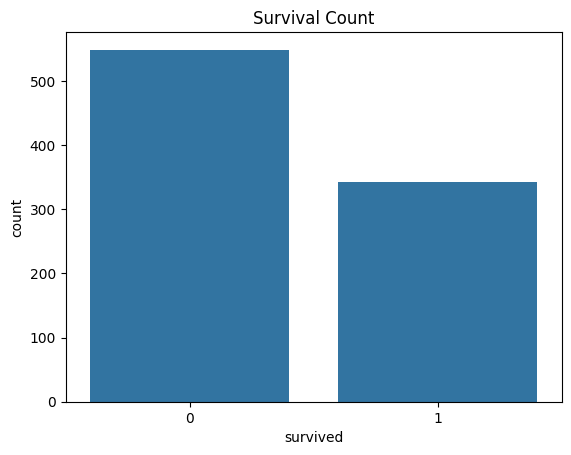

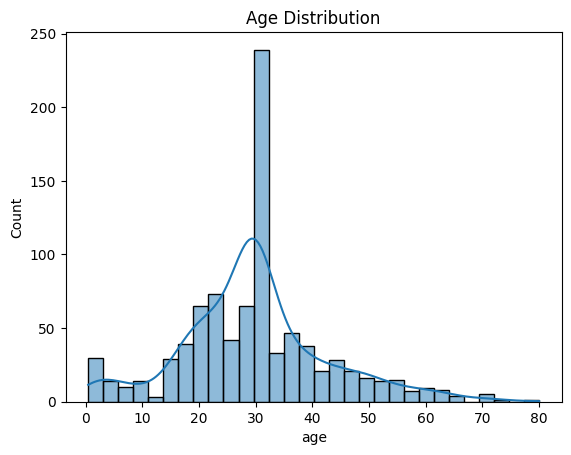

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[88 17]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load Dataset (Seaborn built-in dataset)
df = sns.load_dataset('titanic')

# Step 3: Basic Inspection
print(df.head())
print(df.info())
print(df.isnull().sum())

# Step 4: Data Preprocessing

# Select useful columns
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

# Handle missing values
imputer = SimpleImputer(strategy='mean')
df['age'] = imputer.fit_transform(df[['age']])

df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# Step 5: Exploratory Data Analysis (EDA)

# Survival count
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

# Age distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Step 6: Feature Scaling
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

# Step 7: Split Data
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Model Building
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 9: Prediction
y_pred = model.predict(X_test)

# Step 10: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

**Conclusion**

In this experiment, we studied the complete data science pipeline, including data preprocessing, exploratory data analysis (EDA), feature encoding, feature scaling, and feature engineering. We understood how proper data preparation and transformation techniques improve the quality of data and enhance model performance.

EDA helped in identifying patterns and relationships, while encoding and scaling ensured that the data was suitable for machine learning algorithms. Feature engineering further improved the model by creating meaningful features from raw data.

Overall, the experiment demonstrated that well-prepared data and effective feature design play a crucial role in building accurate and efficient machine learning models.